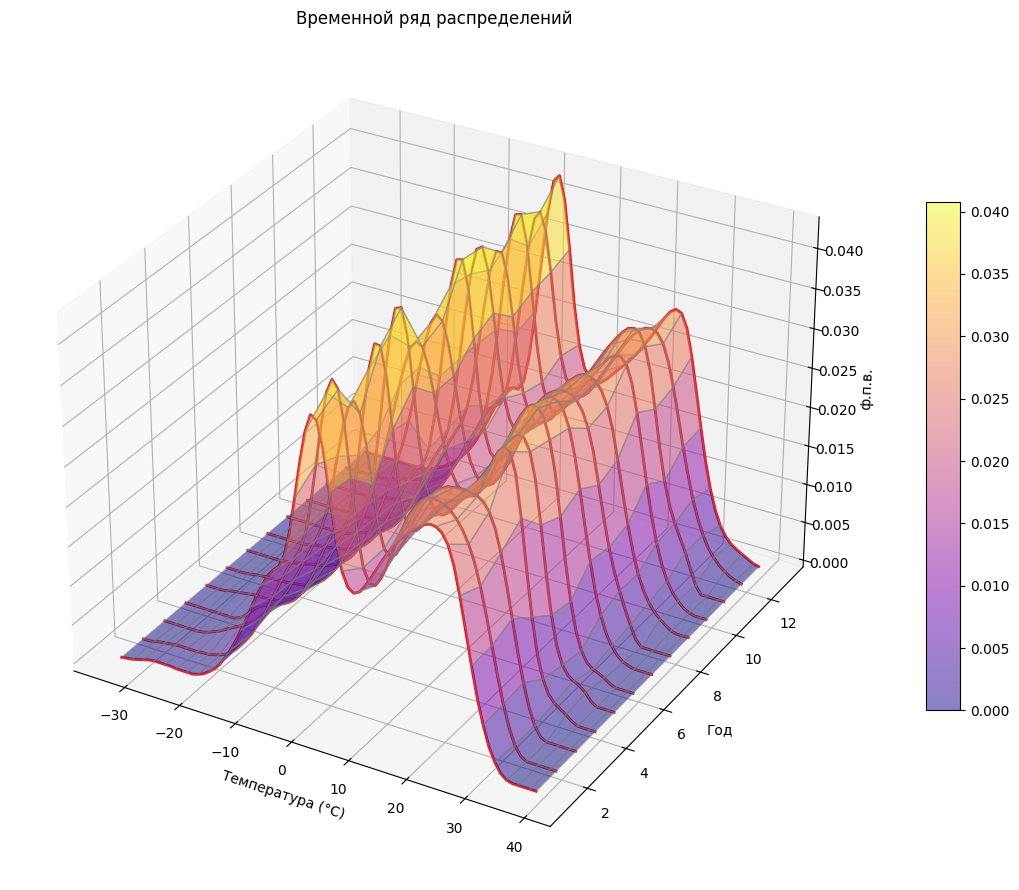

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Загрузка данных
df = pd.read_csv('3Dsf01.txt', sep=r'\s+', header=None, names=['temperature', 'year', 'density'])

# Приведение типов
df['year'] = df['year'].astype(int)
df['temperature'] = df['temperature'].astype(int)

# Общий диапазон температур
all_temps = np.arange(df['temperature'].min(), df['temperature'].max() + 1)  # -34 до 39
years = np.sort(df['year'].unique())  # [1, 2, ..., 13]

# Создание регулярной сетки Z
Z = np.zeros((len(years), len(all_temps)))

# Заполнение Z: для каждого года — плотность по температурам
for i, yr in enumerate(years):
    year_data = df[df['year'] == yr]
    # Создаём словарь температура → плотность
    temp_to_dens = dict(zip(year_data['temperature'], year_data['density']))
    # Заполняем строку Z[i, :]
    for j, t in enumerate(all_temps):
        Z[i, j] = temp_to_dens.get(t, 0.0)  # если температуры нет — 0.0

# Сетка для 3D
X, Y = np.meshgrid(all_temps, years)

# Построение
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# Поверхность
#surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9, edgecolor='none', linewidth=0)

# Красные линии — сечения по годам
for i, yr in enumerate(years):
    ax.plot(all_temps, [yr] * len(all_temps), Z[i, :], color='red', linewidth=2)

# Оформление
ax.set_xlabel('Температура (°C)')
ax.set_ylabel('Год')
ax.set_zlabel('ф.п.в.')
ax.set_title('Временной ряд распределений')

# Цветовая шкала
surf = ax.plot_surface(
    X, Y, Z,
    cmap='plasma',
    alpha=0.5,
    edgecolor='gray'
)
fig.colorbar(surf, shrink=0.6, aspect=15)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Загрузка данных ---
# Красные линии — индивидуальные по годам
df_red = pd.read_csv('3Dsf01.txt', sep=r'\s+', header=None, names=['temperature', 'year', 'density'])
df_red['year'] = df_red['year'].astype(int)

# Синие линии — одинаковые для всех лет
df_blue = pd.read_csv('3Dsfp_01.txt', sep=r'\s+', header=None, names=['temperature', 'year', 'density'])
# Берём данные для одного года (например, year=1) — они одинаковы для всех
blue_curve = df_blue[df_blue['year'] == 1][['temperature', 'density']].sort_values('temperature')
temps_blue = blue_curve['temperature'].values
dens_blue = blue_curve['density'].values

# Уникальные годы (1–13)
years = np.arange(1, 14)

# --- Построение графика ---
fig = plt.figure(figsize=(12, 14))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect([1.7, 1, 1])  # [X, Y, Z] — относительные пропорции

# Синие линии — одинаковая кривая для каждого года
#for yr in years:
#    ax.plot(temps_blue, [yr] * len(temps_blue), dens_blue, color='blue', linewidth=1.2, alpha=0.7)

# Красные линии — индивидуальные данные по годам
for yr in years:
    year_data = df_red[df_red['year'] == yr].sort_values('temperature')
    temps_red = year_data['temperature'].values
    dens_red = year_data['density'].values
    ax.plot(temps_red, [yr] * len(temps_red), dens_red, color='red', linewidth=2, alpha=0.95)

# Оформление
ax.set_xlabel('Температура (°C)')
ax.set_ylabel('Год')
ax.set_zlabel('ф.п.в.')
ax.set_title('Временной ряд распределений')


# --- Синяя поверхность (однотонная, полупрозрачная) ---
# Берём уникальные температуры и соответствующие плотности (они одинаковы для всех лет)
blue_ref = df_blue[df_blue['year'] == 1].sort_values('temperature')
temps_all = blue_ref['temperature'].values
dens_all = blue_ref['density'].values

# Создаём сетку: X — температура, Y — года, Z — повторённая плотность для каждого года
Y_blue = np.arange(1, 14)  # года 1–13
X_surf, Y_surf = np.meshgrid(temps_all, Y_blue)
Z_surf = np.tile(dens_all, (len(Y_blue), 1))  # копируем строку плотности для каждого года

# Строим поверхность
ax.plot_surface(
    X_surf, Y_surf, Z_surf,
    color='blue',          # однотонный синий
    alpha=0.2,             # полупрозрачность
    linewidth=0,
    edgecolor='none',
    shade=False            # отключаем тени, чтобы цвет был равномерным
)


# --- Добавление линий каждые 5 градусов (параллельно оси Y) ---
# Получаем синюю кривую (один раз, для года 1 — все одинаковые)
blue_ref = df_blue[df_blue['year'] == 1].set_index('temperature')['density']

# Температуры каждые 5 градусов в диапазоне данных
temp_ticks = np.arange(-35, 41, 1)  # от -35 до 40 включительно

# Годы
years = np.arange(1, 14)

for t in temp_ticks:
    if t in blue_ref.index:
        z_val = blue_ref[t]
        # Линия: X = t, Y = [1..13], Z = z_val
        ax.plot([t] * len(years), years, [z_val] * len(years),
                color='blue', linewidth=1, alpha=0.8)


# Убираем сетку для чистоты (опционально)
#ax.grid(False)

plt.tight_layout()
plt.show()




FileNotFoundError: [Errno 2] No such file or directory: '3Dsf01.txt'

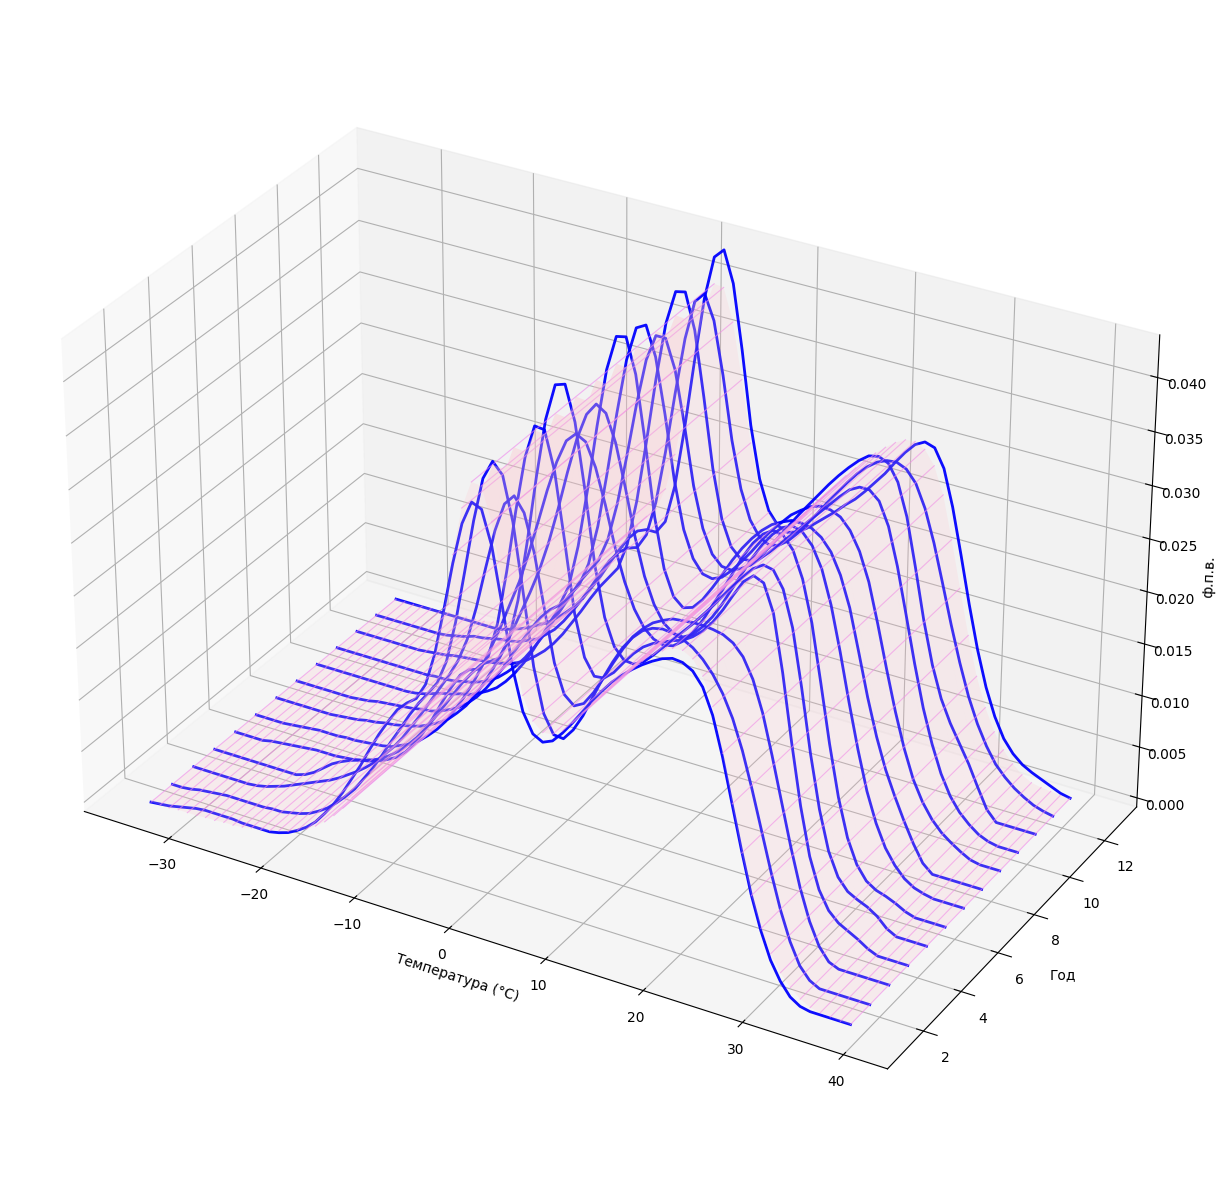

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Загрузка данных ---
# Загрузка красных данных (индивидуальные по годам)
df_red_raw = pd.read_csv('3Dsf01.txt', sep=r'\s+', header=None, names=['temperature', 'year', 'density'])
df_red_raw['year'] = df_red_raw['year'].astype(int)
df_red_raw['temperature'] = df_red_raw['temperature'].astype(int)

# Полный диапазон температур
temps_full = np.arange(-34, 40)  # -34, -33, ..., 39

# Список для полных данных
rows = []

# Для каждого года от 1 до 13
for yr in range(1, 14):
    # Выбираем данные для этого года
    year_data = df_red_raw[df_red_raw['year'] == yr]
    # Создаём Series: температура -> плотность
    dens_dict = dict(zip(year_data['temperature'], year_data['density']))
    # Добавляем все температуры из полного диапазона
    for t in temps_full:
        dens = dens_dict.get(t, 0.0)  # если нет — 0.0
        rows.append({'temperature': t, 'year': yr, 'density': dens})

# Создаём новый DataFrame с полными данными
df_red = pd.DataFrame(rows)

# Синие линии — одинаковые для всех лет
df_blue = pd.read_csv('3Dsfp_01.txt', sep=r'\s+', header=None, names=['temperature', 'year', 'density'])
# Берём данные для одного года (например, year=1) — они одинаковы для всех
blue_curve = df_blue[df_blue['year'] == 1][['temperature', 'density']].sort_values('temperature')
temps_blue = blue_curve['temperature'].values
dens_blue = blue_curve['density'].values

# Уникальные годы (1–13)
years = np.arange(1, 14)

# --- Построение графика ---
fig = plt.figure(figsize=(12, 14))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect([1.7, 1, 1])  # [X, Y, Z] — относительные пропорции

# Синие линии — одинаковая кривая для каждого года
#for yr in years:
#    ax.plot(temps_blue, [yr] * len(temps_blue), dens_blue, color='blue', linewidth=1.2, alpha=0.7)
"""
# Синие линии со смещением: Y = 1.5, 2.5, ..., 12.5
for i in range(12):  # 0..11 → 12 линий
    y_pos = 1.5 + i  # 1.5, 2.5, ..., 12.5
    ax.plot(temps_all, [y_pos] * len(temps_all), dens_all,
            color='blue', linewidth=0.8, alpha=0.6)
"""

# Красные линии — индивидуальные данные по годам
for yr in years:
    year_data = df_red[df_red['year'] == yr].sort_values('temperature')
    temps_red = year_data['temperature'].values
    dens_red = year_data['density'].values
    ax.plot(temps_red, [yr] * len(temps_red), dens_red, color='blue', linewidth=2, alpha=0.95)

# Оформление
ax.set_xlabel('Температура (°C)')
ax.set_ylabel('Год')
ax.set_zlabel('ф.п.в.')
#ax.set_title('Временной ряд распределений')


# --- Синяя поверхность (однотонная, полупрозрачная) ---
# Берём уникальные температуры и соответствующие плотности (они одинаковы для всех лет)
blue_ref = df_blue[df_blue['year'] == 1].sort_values('temperature')
temps_all = blue_ref['temperature'].values
dens_all = blue_ref['density'].values

# Создаём сетку: X — температура, Y — года, Z — повторённая плотность для каждого года
Y_blue = np.arange(1, 14)  # года 1–13
X_surf, Y_surf = np.meshgrid(temps_all, Y_blue)
Z_surf = np.tile(dens_all, (len(Y_blue), 1))  # копируем строку плотности для каждого года

# Строим поверхность
ax.plot_surface(
    X_surf, Y_surf, Z_surf,
    color='pink',          # однотонный синий
    alpha=0.2,             # полупрозрачность
    linewidth=0,
    edgecolor='none',
    shade=False            # отключаем тени, чтобы цвет был равномерным
)


# --- Добавление линий каждые 5 градусов (параллельно оси Y) ---
# Получаем синюю кривую (один раз, для года 1 — все одинаковые)
blue_ref = df_blue[df_blue['year'] == 1].set_index('temperature')['density']

# Температуры каждые 5 градусов в диапазоне данных
temp_ticks = np.arange(-35, 41, 1)  # от -35 до 40 включительно

# Годы
years = np.arange(1, 14)

for t in temp_ticks:
    if t in blue_ref.index:
        z_val = blue_ref[t]
        # Линия: X = t, Y = [1..13], Z = z_val
        ax.plot([t] * len(years), years, [z_val] * len(years),
                color='violet', linewidth=0.8, alpha=0.6)


# Убираем сетку для чистоты (опционально)
#ax.grid(False)
#plt.savefig('Moscow_temperature_disrtibution_1960-2020', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()